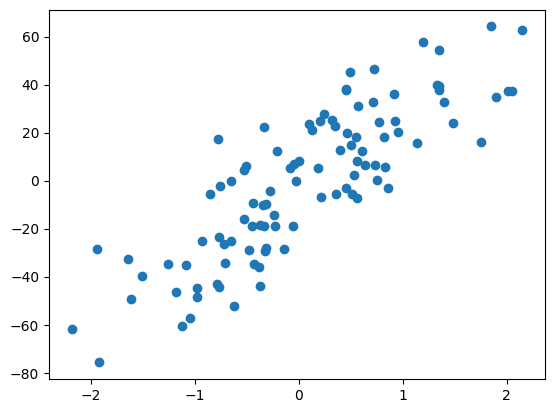

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
plt.scatter(X,y)

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)
# Overfitting as higher variance due to greater m
print("R2_score:",r2_score(lr.predict(X),y))

[27.82809103]
-2.29474455867698
R2_score: 0.5785727452828358


In [7]:
from sklearn.linear_model import Lasso
ll = Lasso(alpha=0.1)
ll.fit(X,y)
print(ll.coef_)
print(ll.intercept_)
# best tradeoff 
print("R2_score:",r2_score(ll.predict(X),y))

[27.71294347]
-2.288019090203184
R2_score: 0.575046136663708


0.7823874182052571
0.7814853364469552
0.7598353742477061
0.692179242375053
0.0


c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\KIIT0001\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.649e+03, tolerance: 2.435e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordina

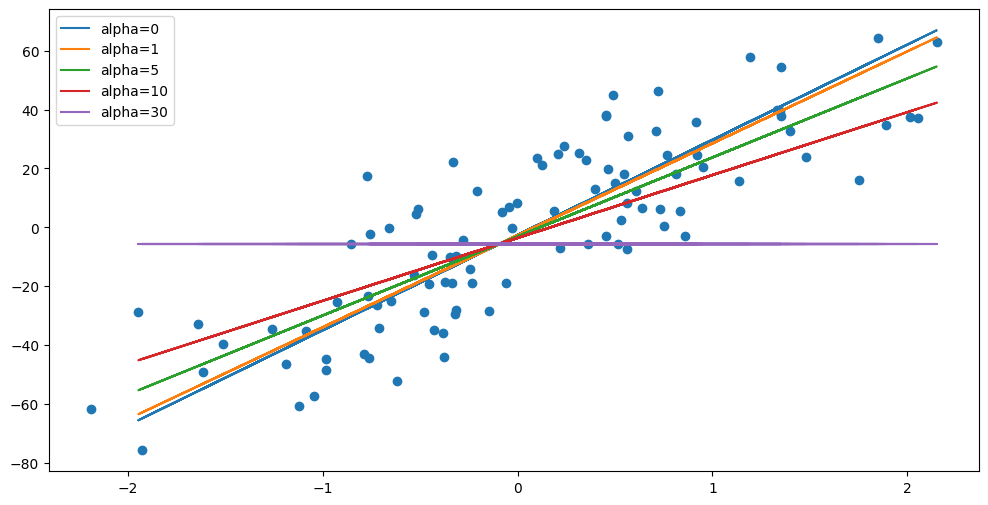

In [11]:
alphas = [0,1,5,10,30]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2,random_state=2)
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    print(r2_score(y_train,L.predict(X_train)))
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()